# Лабораторна робота 2. Аналіз датасету

**Виконали:** Перькова Єлизавета

**Датасет:** House Prices: Advanced Regression Techniques (Kaggle) — табличні дані про продаж будинків у м. Еймс, штат Айова.

Для лабораторної обрано саме цей набір даних замість MNIST з лабораторної 1, оскільки MNIST складається з пікселів зображень і погано підходить для роботи з `pandas`. House Prices — табличний датасет (1460 рядків, 81 колонка) з числовими і категоріальними ознаками та пропусками, тому на ньому можна продемонструвати більше пунктів завдання.

## 1. Завантаження даних

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("house_prices.csv")
type(df)

pandas.DataFrame

Файл у форматі CSV, тому використано `pd.read_csv()`.

## 2. Попередній огляд даних

### 2.1 Перші та останні 5 рядків

In [2]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


### 2.2 Кількість рядків та колонок

In [4]:
rows, cols = df.shape
print("Кількість рядків: ", rows)
print("Кількість колонок: ", cols)

Кількість рядків:  1460
Кількість колонок:  81


### 2.3 Назви колонок, типи даних та короткий опис

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

Короткий опис ключових колонок (повний опис усіх 81 ознаки є у файлі `data_description.txt` офіційного датасету, тут наведено найважливіші):

| Колонка | Опис |
|---|---|
| `Id` | ідентифікатор будинку |
| `MSSubClass` | клас будівлі (тип житла) |
| `MSZoning` | зональна класифікація ділянки |
| `LotFrontage` | довжина фасаду ділянки (фути) |
| `LotArea` | площа ділянки (кв. фути) |
| `Neighborhood` | район міста |
| `OverallQual` | загальна якість матеріалів і оздоблення (1–10) |
| `OverallCond` | загальний стан будинку (1–10) |
| `YearBuilt` | рік побудови |
| `YearRemodAdd` | рік останнього ремонту |
| `GrLivArea` | житлова площа (кв. фути) |
| `FullBath` | кількість повних санвузлів |
| `BedroomAbvGr` | кількість спалень над цоколем |
| `GarageCars` | місткість гаража (кількість авто) |
| `SalePrice` | ціна продажу будинку ($) — цільова змінна |

### 2.4 Кількість пропущених значень у кожному стовпці

In [6]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

### 2.5 Типи ознак: категоріальні, числові, часові

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print("Числових колонок: ", len(numeric_cols))
print("Категоріальних колонок: ", len(categorical_cols))

Числових колонок:  38
Категоріальних колонок:  43


/var/folders/ml/x1vf11ss7mxcbd6qm5wbmgjm0000gn/T/ipykernel_3532/2312970538.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns.tolist()


Окремих колонок типу `datetime` у датасеті немає. Є колонки з роком і місяцем продажу (`YrSold`, `MoSold`) та роком побудови чи ремонту (`YearBuilt`, `YearRemodAdd`, `GarageYrBlt`), які за змістом є часовими, хоча зберігаються як числа.

### 2.6 Перевірка на дублікати

In [8]:
df.duplicated().sum()

np.int64(0)

Повних дублікатів рядків у датасеті немає.

### 2.7 Розподіл деяких числових/категоріальних ознак

In [9]:
df[["SalePrice", "GrLivArea", "OverallQual", "YearBuilt"]].describe()

,SalePrice,GrLivArea,OverallQual,YearBuilt
count,1460.000000,1460.000000,1460.000000,1460.000000
mean,180921.195890,1515.463699,6.099315,1971.267808
std,79442.502883,525.480383,1.382997,30.202904
min,34900.000000,334.000000,1.000000,1872.000000
25%,129975.000000,1129.500000,5.000000,1954.000000
50%,163000.000000,1464.000000,6.000000,1973.000000
75%,214000.000000,1776.750000,7.000000,2000.000000
max,755000.000000,5642.000000,10.000000,2010.000000


In [10]:
df["Neighborhood"].value_counts().head(10)

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
Name: count, dtype: int64

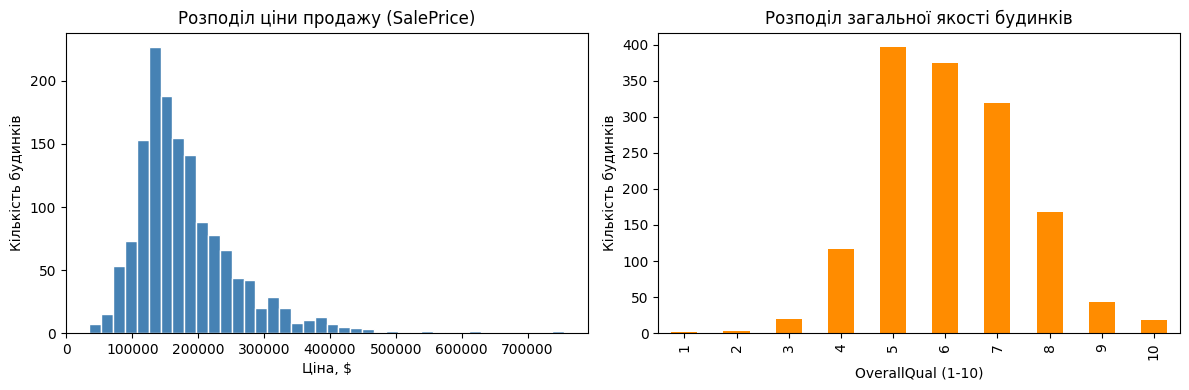

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["SalePrice"], bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Розподіл ціни продажу (SalePrice)")
axes[0].set_xlabel("Ціна, $")
axes[0].set_ylabel("Кількість будинків")

df["OverallQual"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Розподіл загальної якості будинків")
axes[1].set_xlabel("OverallQual (1-10)")
axes[1].set_ylabel("Кількість будинків")

plt.tight_layout()
plt.show()

### 2.8 Кореляція числових ознак із ціною

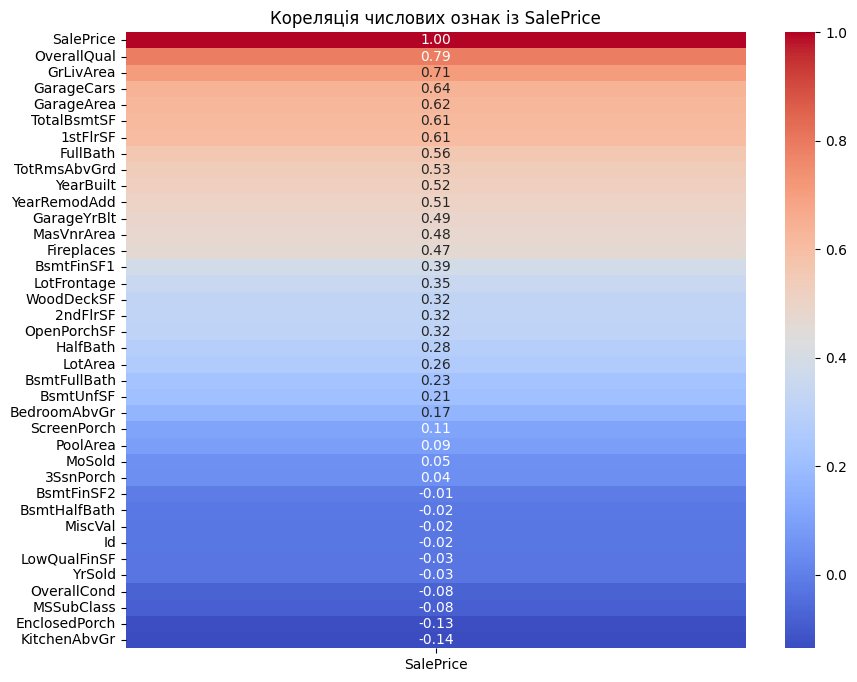

In [12]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix[["SalePrice"]].sort_values(by="SalePrice", ascending=False),
            annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Кореляція числових ознак із SalePrice")
plt.show()

З ціною найбільше корелюють `OverallQual`, `GrLivArea` і `GarageCars`. Не дуже очікувала, що `GarageCars` опиниться так високо — здавалось, що площа і якість будуть домінувати набагато сильніше.

## 3. Препроцесинг / Попередня обробка даних

### 3.1 Видалення колонок з надмірною кількістю пропусків

Колонки `PoolQC`, `MiscFeature`, `Alley`, `Fence` мають понад 80% пропущених значень. Специфіка цього датасету в тому, що `NaN` тут зазвичай означає відсутність відповідного елемента (наприклад, немає басейну — немає опису його якості), а не помилку при зборі даних. Проте через настільки високу частку пропусків ці колонки майже не несуть статистичної інформації, тому для подальшого аналізу їх видалено.

In [13]:
cols_to_drop = ["PoolQC", "MiscFeature", "Alley", "Fence"]
df_clean = df.drop(columns=cols_to_drop)
df_clean.shape

(1460, 77)

### 3.2 Заповнення пропущених значень

Один `fillna()` на весь датасет тут не підходить — причина пропуску в різних колонках різна. `LotFrontage` (довжина фасаду) заповнюємо медіаною по району (`Neighborhood`), бо ділянки в одному районі зазвичай схожі за розміром. `MasVnrType` і `MasVnrArea` — пропуск означає, що облицювання цеглою просто немає, тому ставимо `"None"` і `0`.

Те саме стосується `FireplaceQu`, `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`, `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2` — це категоріальні ознаки, де `NaN` означає відсутність елемента (немає каміна, гаража чи підвалу), тому теж `"None"`.

З `GarageYrBlt` довго думали, чи ставити 0 чи лишити NaN. Зупинились на 0 — так простіше для подальших обчислень, хоча, можливо, не найкоректніше рішення. `Electrical` має лише один пропуск, тому просто заповнили модою (найчастішим значенням).

In [14]:
neighborhood_median = df_clean.groupby("Neighborhood")["LotFrontage"].median()
print(neighborhood_median.head())

df_clean["LotFrontage"] = df_clean["LotFrontage"].fillna(df_clean["Neighborhood"].map(neighborhood_median))

# підстраховка: якщо в якомусь районі медіана теж виявиться NaN (наприклад, всі значення були пропущені)
df_clean["LotFrontage"] = df_clean["LotFrontage"].fillna(df_clean["LotFrontage"].median())

df_clean["MasVnrType"] = df_clean["MasVnrType"].fillna("None")
df_clean["MasVnrArea"] = df_clean["MasVnrArea"].fillna(0)

none_cols = ["FireplaceQu", "GarageType", "GarageFinish", "GarageQual", "GarageCond",
             "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2"]
for c in none_cols:
    df_clean[c] = df_clean[c].fillna("None")

df_clean["GarageYrBlt"] = df_clean["GarageYrBlt"].fillna(0)
df_clean["Electrical"] = df_clean["Electrical"].fillna(df_clean["Electrical"].mode()[0])

print("Залишилось пропусків:", df_clean.isna().sum().sum())

Neighborhood
Blmngtn    43.0
Blueste    24.0
BrDale     21.0
BrkSide    52.0
ClearCr    80.0
Name: LotFrontage, dtype: float64
Залишилось пропусків: 0


### 3.3 Перетворення форматів даних

`MSSubClass` фактично є категорією (код типу будівлі), хоча зберігається як число, тому переводимо її у `str`. `GarageYrBlt` приводимо до `int`, бо дробова частина року не має сенсу.

In [15]:
df_clean["MSSubClass"] = df_clean["MSSubClass"].astype(str)
df_clean["GarageYrBlt"] = df_clean["GarageYrBlt"].astype(int)

df_clean[["MSSubClass", "GarageYrBlt"]].dtypes

MSSubClass       str
GarageYrBlt    int64
dtype: object

### 3.4 Створення нових колонок з похідними ознаками

- **`HouseAge`** — вік будинку на момент продажу (`YrSold - YearBuilt`).
- **`TotalSF`** — сумарна площа (підвал + 1-й + 2-й поверх).
- **`RemodAge`** — скільки років минуло від останнього ремонту до продажу.

In [16]:
df_clean["HouseAge"] = df_clean["YrSold"] - df_clean["YearBuilt"]
df_clean["TotalSF"] = df_clean["TotalBsmtSF"] + df_clean["1stFlrSF"] + df_clean["2ndFlrSF"]
df_clean["RemodAge"] = df_clean["YrSold"] - df_clean["YearRemodAdd"]

df_clean[["YearBuilt", "YrSold", "HouseAge", "TotalSF", "RemodAge"]].head()

,YearBuilt,YrSold,HouseAge,TotalSF,RemodAge
0,2003,2008,5,2566,5
1,1976,2007,31,2524,31
2,2001,2008,7,2706,6
3,1915,2006,91,2473,36
4,2000,2008,8,3343,8


In [17]:
df_clean[["TotalSF", "SalePrice"]].corr()

,TotalSF,SalePrice
TotalSF,1.00000,0.78226
SalePrice,0.78226,1.00000


`TotalSF` непогано корелює з ціною, тож ця ознака справді корисна.

### 3.5 Перейменування колонок для зручності

In [18]:
df_clean = df_clean.rename(columns={
    "GrLivArea": "LivingAreaAboveGround",
    "SalePrice": "Price"
})
df_clean.columns[:10]

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig'],
      dtype='str')

### 3.6 Видалення зайвої колонки

`Id` — технічний ідентифікатор рядка, не несе аналітичної цінності.

In [19]:
df_clean = df_clean.drop(columns=["Id"])
df_clean.shape

(1460, 79)

## 4. Спостереження

Завдання було провести первинний аналіз і підготувати House Prices до подальшої роботи. Датасет — 1460 будинків у м. Еймс, 81 ознака, від площі ділянки до якості оздоблення. У ціни (`Price`) правосторонньо скошений розподіл — більшість будинків недорогі, але є невелика частка значно дорожчих, і саме вони найбільше зміщують розподіл вправо. Серед незвичних значень помітила, що більше половини будинків (829 із 1460) мають `2ndFlrSF` рівний 0 — спочатку здалось дивним, але це просто одноповерхові будинки без другого поверху.

Найбільше часу пішло на пропущені значення. В багатьох колонках `NaN` — це не помилка, а відсутність елемента (немає гаража — немає й опису гаража), тому довелось заповнювати окремо для різних груп, а не одним способом. Окрема складність була з `LotFrontage`: спочатку хотіла просто заповнити загальною медіаною, але зрозуміла, що в різних районах розмір ділянок дуже різний, тому довелось рахувати медіану по `Neighborhood` — і навіть тоді додала підстраховку на випадок, якщо в якомусь районі взагалі немає жодного відомого значення.

`Id`, `PoolQC`, `MiscFeature`, `Alley`, `Fence` прибрала: перша не несе інформації, інші — майже суцільні пропуски (`PoolQC` пропущено 99.5%, `MiscFeature` — 96.3%, `Alley` — 93.8%). З `Fence` довше вагалась, бо там все ж є 19.2% заповнених значень, але вирішила, що для цього рівня аналізу це не критично.

Найсильніше з ціною пов'язані `OverallQual`, `GrLivArea` і новостворена ознака `TotalSF`. Дані виглядають готовими до подальшого EDA, хоча категоріальні змінні ще треба буде закодувати, наприклад One-Hot Encoding.